In [18]:
#shap!!
import shap

import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

In [19]:
import glob
import numpy as np
import tifffile as tiff
import pandas as pd
from skimage.transform import resize
import re
import skimage.transform as skt

# Specify the directory path where the .tif images are located
directory_path_1 = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30\*.tif'
directory_path_2 = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO2\08-30\*.tif'

# Retrieve the file paths of all .tif images in the directory
image_paths = glob.glob(directory_path_1) + glob.glob(directory_path_2)

# Extract the labels from the filenames
labels = [path.split('_')[-1].split('.')[0] for path in image_paths]

# Load and resize the .tif images
flattened_images = []
label_list = []
image_data = []

for path, label in zip(image_paths, labels):
    match = re.search(r'(\w+)\s*(?:\(\d+\))?', label)
    if match:
        extracted_label = match.group(1)
        if extracted_label != 'None':  # Ignore images with the label 'None'
            image = tiff.imread(path)
            resized_image = skt.resize(image, (128, 128), mode='reflect')  # Resize to 128x128
            flattened_image = resized_image.flatten()  # Flatten the image
            flattened_images.append(flattened_image)
            label_list.append(label)
    else:
        extracted_label = label
        if extracted_label != 'None':  # Ignore images with the label 'None'
            image = tiff.imread(path)
            resized_image = skt.resize(image, (128, 128), mode='reflect')  # Resize to 128x128
            flattened_image = resized_image.flatten()  # Flatten the image
            flattened_images.append(flattened_image)
            label_list.append(label)

# Get the maximum size along dimension 1
max_size = max(flattened_image.size for flattened_image in flattened_images)

# Reshape the flattened images to have a consistent size along dimension 1
reshaped_images = [np.pad(flattened_image, (0, max_size - flattened_image.size), mode='constant') for flattened_image in flattened_images]

# Stack the reshaped images
combined_matrix = np.vstack(reshaped_images)

# Create column names for the DataFrame
column_names = [f'Pixel_{i}' for i in range(combined_matrix.shape[1])]

# Convert the combined matrix to a DataFrame and add labels
df = pd.DataFrame(combined_matrix, columns=column_names)
df['Label'] = label_list

# Write the DataFrame to a .csv file
output_path = 'output-images.csv' # Replace with your desired output file path
df.to_csv(output_path, index=False)
#X = (train_df.iloc[:,1:].values).astype('float32')
#Y = train_df.iloc[:,0].values.astype('int32')
#test = test_df.values.astype('float32')

In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the preprocessed dataset
df = pd.read_csv('output-images.csv')  # Replace with the path to your preprocessed dataset CSV file
print(df.shape)

# Display the possible labels
print(df['Label'].value_counts())

# Categorize AVARAGE as UNHEALTHY
df['Label'] = df['Label'].replace('AVERAGE', 'UNHEALTHY')

# Remove the '0830'and 'ALL' samples/labels
df = df[df['Label'] != '0830']
df = df[df['Label'] != 'ALL']

# Split the dataset into features (X) and labels (y)
X = df.drop('Label', axis=1).values
y = df['Label'].values


# Display the possible labels
print(df['Label'].value_counts())


(594, 81921)
AVARAGE      430
HEALTHY      106
UNHEALTHY     56
0830           1
ALL            1
Name: Label, dtype: int64
AVARAGE      430
HEALTHY      106
UNHEALTHY     56
Name: Label, dtype: int64
['AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE'
 'AVARAGE' 'AVARAGE' 'UNHEALTHY' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE'
 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE'
 'UNHEALTHY' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'UNHEALTHY' 'AVARAGE'
 'AVARAGE' 'UNHEALTHY' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'HEALTHY'
 'AVARAGE' 'AVARAGE' 'HEALTHY' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'HEALTHY'
 'AVARAGE' 'AVARAGE' 'UNHEALTHY' 'UNHEALTHY' 'UNHEALTHY' 'UNHEALTHY'
 'AVARAGE' 'UNHEALTHY' 'UNHEALTHY' 'AVARAGE' 'UNHEALTHY' 'AVARAGE'
 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE'
 'AVARAGE' 'AVARAGE' 'UNHEALTHY' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE'
 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE' 'AVARAGE'
 'AVARAGE' 'AV

In [27]:
# Categorize AVARAGE as UNHEALTHY
df['Label'] = df['Label'].replace('AVARAGE', 'UNHEALTHY')

# Remove the '0830'and 'ALL' samples/labels
df = df[df['Label'] != '0830']
df = df[df['Label'] != 'ALL']

# Split the dataset into features (X) and labels (y)
X = df.drop('Label', axis=1).values
y = df['Label'].values

# Perform label encoding for categorical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Convert the integer labels to one-hot encoded vectors
num_classes = len(label_encoder.classes_)
y = to_categorical(y, num_classes=num_classes)

# Print the label counts
print(df['Label'].value_counts())


UNHEALTHY    486
HEALTHY      106
Name: Label, dtype: int64


In [28]:

# Split the data into train, test, and validation sets:
# 70% train, 20% test, and 10% validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the test set into test and validation sets
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.33, random_state=42)

# Save the validation set and its labels to a .csv file
val_df = pd.DataFrame(X_val)
val_df['Label'] = label_encoder.inverse_transform(np.argmax(y_val, axis=1))
val_df.to_csv('image-based-validation_set.csv', index=False)

# Reshape the input data to match the CNN input shape (assuming images are grayscale)
input_shape = (128, 128, 5)  # Adjust the input shape based on your image size and channels
X_train = X_train.reshape(-1, *input_shape)
X_test = X_test.reshape(-1, *input_shape)

# Normalize the input data to a range of [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Create the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))

# # Evaluate the model on the test set
# loss, accuracy = model.evaluate(X_test, y_test)
# print(f'Test loss: {loss:.4f}')
# print(f'Test accuracy: {accuracy:.4f}')

# # Generate predictions on the test set
# y_pred = model.predict(X_test)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_test_classes = np.argmax(y_test, axis=1)

# # Decode the one-hot encoded predictions and true labels
# y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
# y_test_labels = label_encoder.inverse_transform(y_test_classes)

# # Print classification report
# print(classification_report(y_test_labels, y_pred_labels))

Epoch 1/10
13/13 [==============================] - 6s 259ms/step - loss: 0.5244 - accuracy: 0.7995 - val_loss: 0.4607 - val_accuracy: 0.8403
Epoch 2/10
13/13 [==============================] - 3s 231ms/step - loss: 0.5183 - accuracy: 0.8237 - val_loss: 0.4397 - val_accuracy: 0.8403
Epoch 3/10
13/13 [==============================] - 4s 288ms/step - loss: 0.4922 - accuracy: 0.8237 - val_loss: 0.5010 - val_accuracy: 0.8403
Epoch 4/10
13/13 [==============================] - 4s 283ms/step - loss: 0.5072 - accuracy: 0.8237 - val_loss: 0.4528 - val_accuracy: 0.8403
Epoch 5/10
13/13 [==============================] - 4s 352ms/step - loss: 0.5063 - accuracy: 0.8237 - val_loss: 0.4523 - val_accuracy: 0.8403
Epoch 6/10
13/13 [==============================] - 4s 269ms/step - loss: 0.4907 - accuracy: 0.8237 - val_loss: 0.4391 - val_accuracy: 0.8403
Epoch 7/10
13/13 [==============================] - 3s 213ms/step - loss: 0.4879 - accuracy: 0.8237 - val_loss: 0.4463 - val_accuracy: 0.8403
Epoch 

C:\Users\flopes1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
C:\Users\flopes1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


2/2 [==============================] - 0s 40ms/step
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)


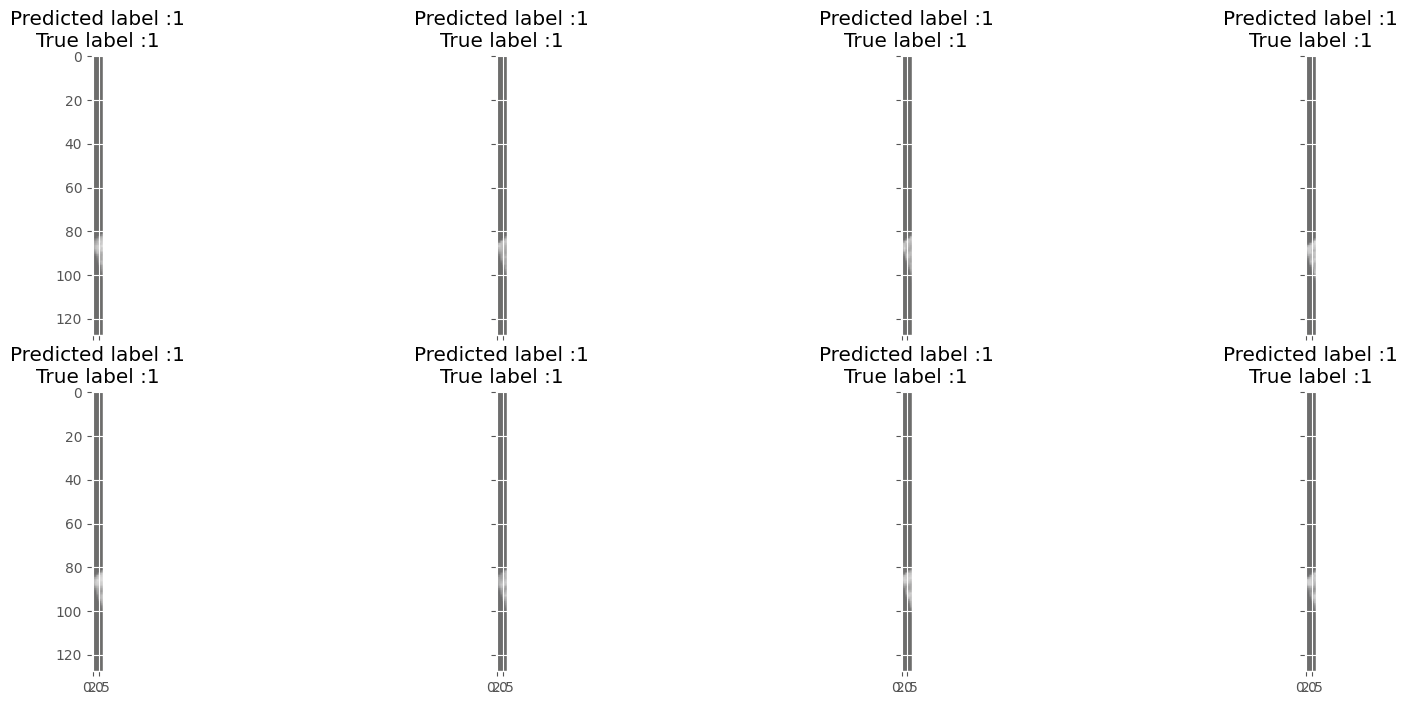

In [49]:
import numpy as np
import shap

# Assuming you have trained your model and defined X_val, y_val, and input_shape earlier in your code

# Reshape the validation data to match the CNN input shape
X_val_reshaped = X_val.reshape(-1, *input_shape)

# Normalize the input data to a range of [0, 1]
X_val_normalized = X_val_reshaped.astype('float32') / 255.0

# Calculate SHAP values for the correctly classified images in the validation set
explainer = shap.DeepExplainer(model, X_train)

shap_values = explainer.shap_values(X_val_normalized)

# Get the predicted classes for the validation set
y_pred = model.predict(X_val_normalized)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Find the indices of correctly classified images
correct_indices = np.where(y_pred_classes == y_true_classes)[0]


(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)
(128, 128, 5)
(128, 128, 5, 2)


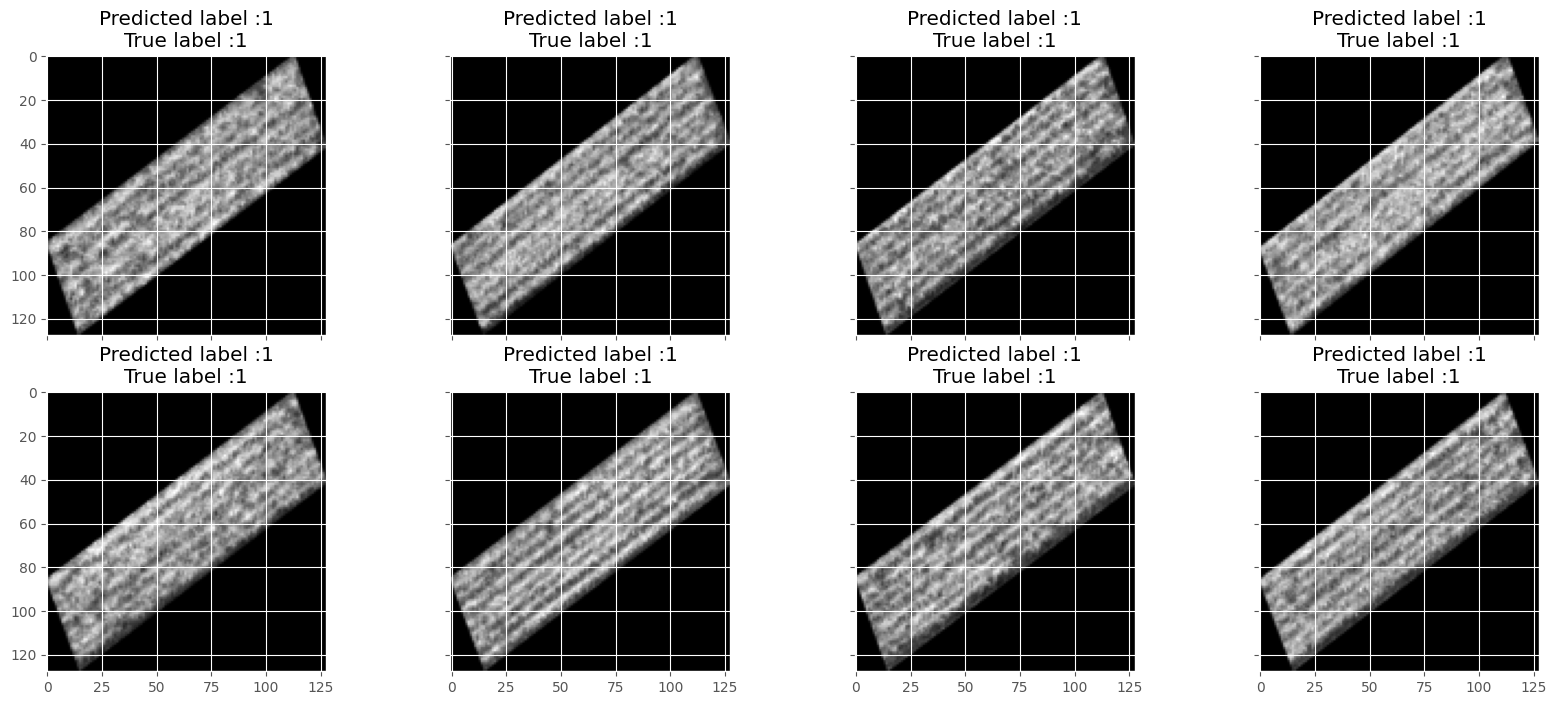

In [53]:
# Display images with SHAP values for correctly classified examples
def display_correct_with_shap(correct_indices, X_val, y_pred_classes, y_true_classes, shap_values):
    """ This function shows images with SHAP values for correctly classified examples"""
    n = 0
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, sharex=True, sharey=True, figsize=(20, 8))
    for row in range(nrows):
        for col in range(ncols):
            index = correct_indices[n]
            image = X_val[index].reshape(128, 128, 5)
            print(image.shape)
            ax[row, col].imshow(image[:, :, 3], cmap='gray')  # Show the image
            ax[row, col].set_title("Predicted label :{}\nTrue label :{}".format(y_pred_classes[index], y_true_classes[index]))

            # Show SHAP values as red-blue overlay
            shap_image = shap_values[index][:, :, :, 1].mean(axis=0)  # Assuming the 4th channel is the relevant one
            ax[row, col].imshow(shap_image, cmap='coolwarm', alpha=0.5, vmin=-1, vmax=1)  # Overlay SHAP values
            n += 1
    plt.show()

# Display correctly classified images with SHAP values
display_correct_with_shap(correct_indices, X_val_normalized, y_pred_classes, y_true_classes, shap_values)

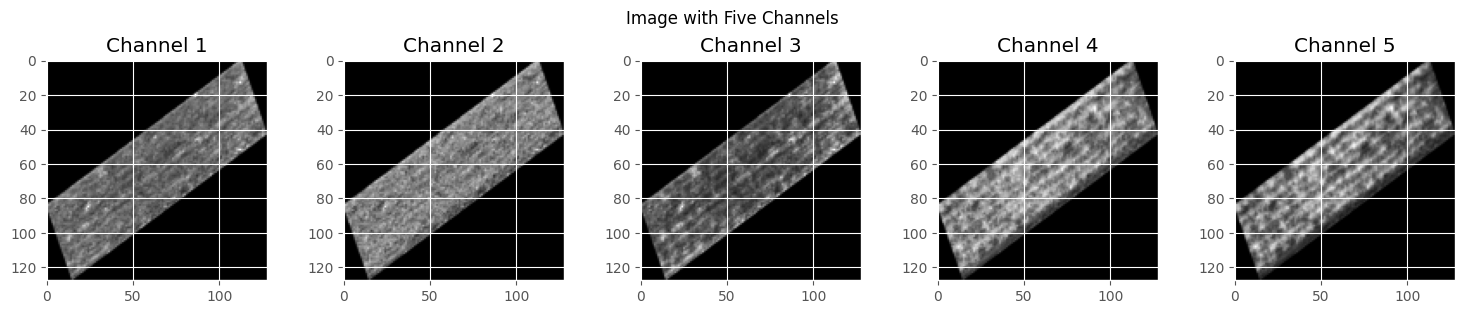

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have an image with shape (height, width, channels)
image = X[0].reshape(128, 128, 5)

# Create a figure and subplot for each channel
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 3))

# Plot each channel separately
for i in range(5):
    channel = image[:, :, i]
    axs[i].imshow(channel, cmap='gray')
    axs[i].set_title(f'Channel {i+1}')

# Set the title of the figure
fig.suptitle('Image with Five Channels')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

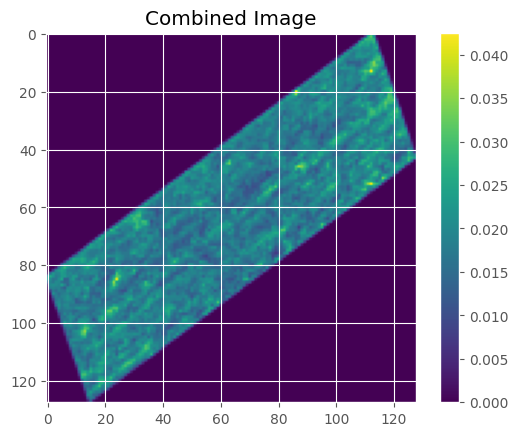

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have an image with shape (height, width, channels)
image = X[0].reshape(128, 128, 5)

# Choose three channels to combine
channel_indices = [0, 1, 2]  # Adjust the channel indices as desired

# Combine the chosen channels
combined_image = np.mean(image[:, :, channel_indices], axis=2)

# Plot the combined image
plt.imshow(combined_image)
plt.title('Combined Image')
plt.colorbar()

# Show the plot
plt.show()

In [31]:
pred = model.predict(X_test)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest accuracy: {test_acc}')

4/4 [==============================] - 0s 51ms/step

Test accuracy: 0.8403361439704895


In [32]:
# Print how many labels exist in the dataset
print(df['Label'].value_counts())

Y_pred_classes = np.argmax(pred,axis = 1) 
Y_true = np.argmax(y_test,axis = 1)

UNHEALTHY    486
HEALTHY      106
Name: Label, dtype: int64


In [42]:
import numpy as np
import shap

# Assuming you have defined Y_pred_classes, Y_true, X_test, and pred earlier in your code

# Calculate SHAP values for the entire test set
print(model)
explainer = shap.DeepExplainer(model, (X_test[0:100]))
print(X_test)
shap_values = explainer.shap_values(X_test)

# Aggregate SHAP values across all samples
mean_shap_values = np.mean(np.abs(shap_values), axis=0)

# Find the channel with the highest mean SHAP value
most_relevant_channel = np.argmax(np.mean(mean_shap_values, axis=(0, 1)))

print("The most relevant channel is:", most_relevant_channel)

C:\Users\flopes1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


[[[[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  ...

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]]


 [[[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
 

C:\Users\flopes1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


The most relevant channel is: 1
